In [40]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns
colors = ('#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
          '#bcbd22', '#17becf')
sns.set(style='ticks', palette=colors)


sns.set_context('talk',font_scale=2,rc={'lines.linewidth':3})

# The following is specific Jupyter notebooks
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}


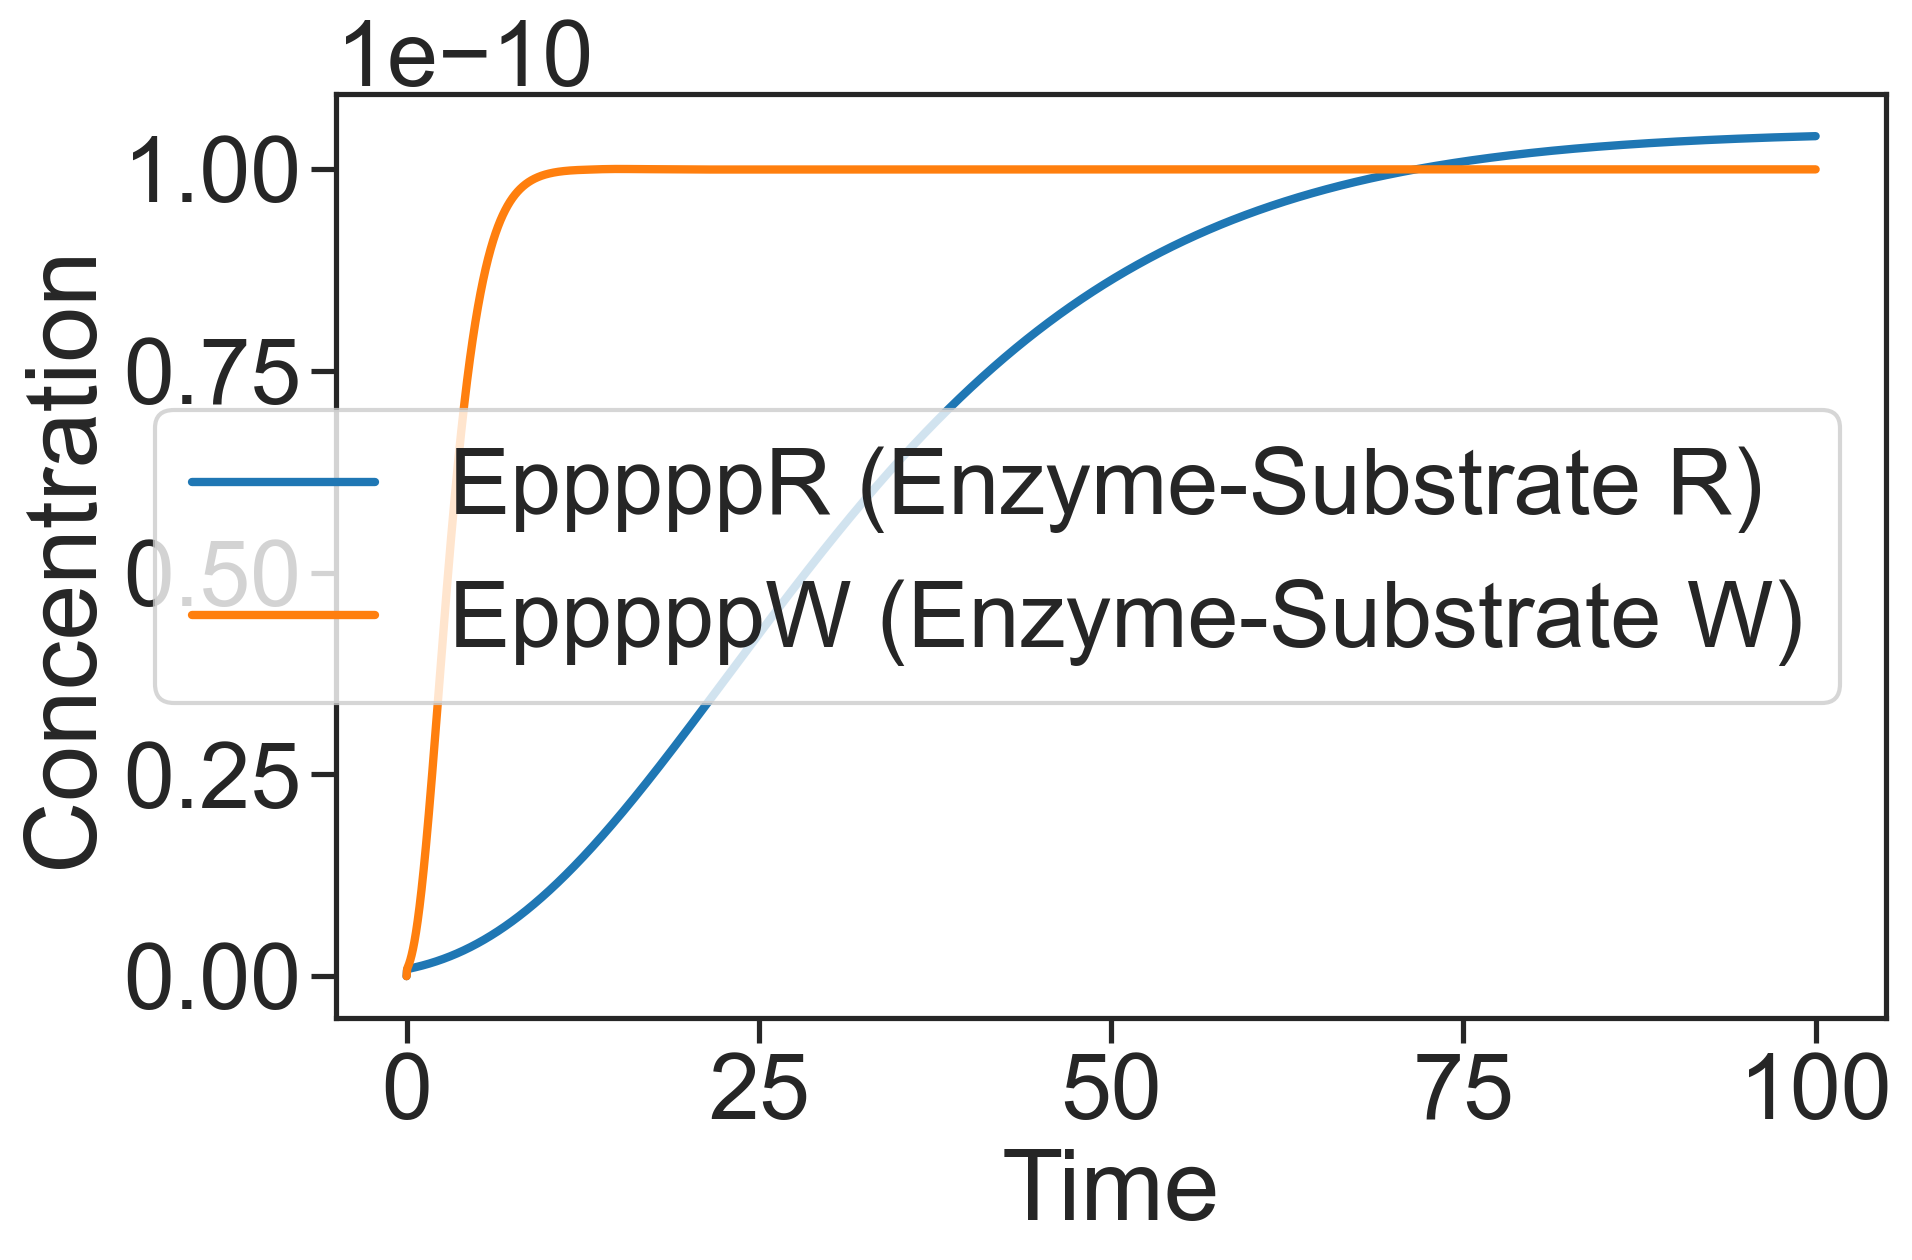

/var/folders/fd/b1g1fr5n7xv98s13rfl1ncyw0000gn/T/ipykernel_63133/751313925.py:87: RuntimeWarning: invalid value encountered in divide
  plt.plot(t, solution_ER[:,7]/solution_EW[:,7])


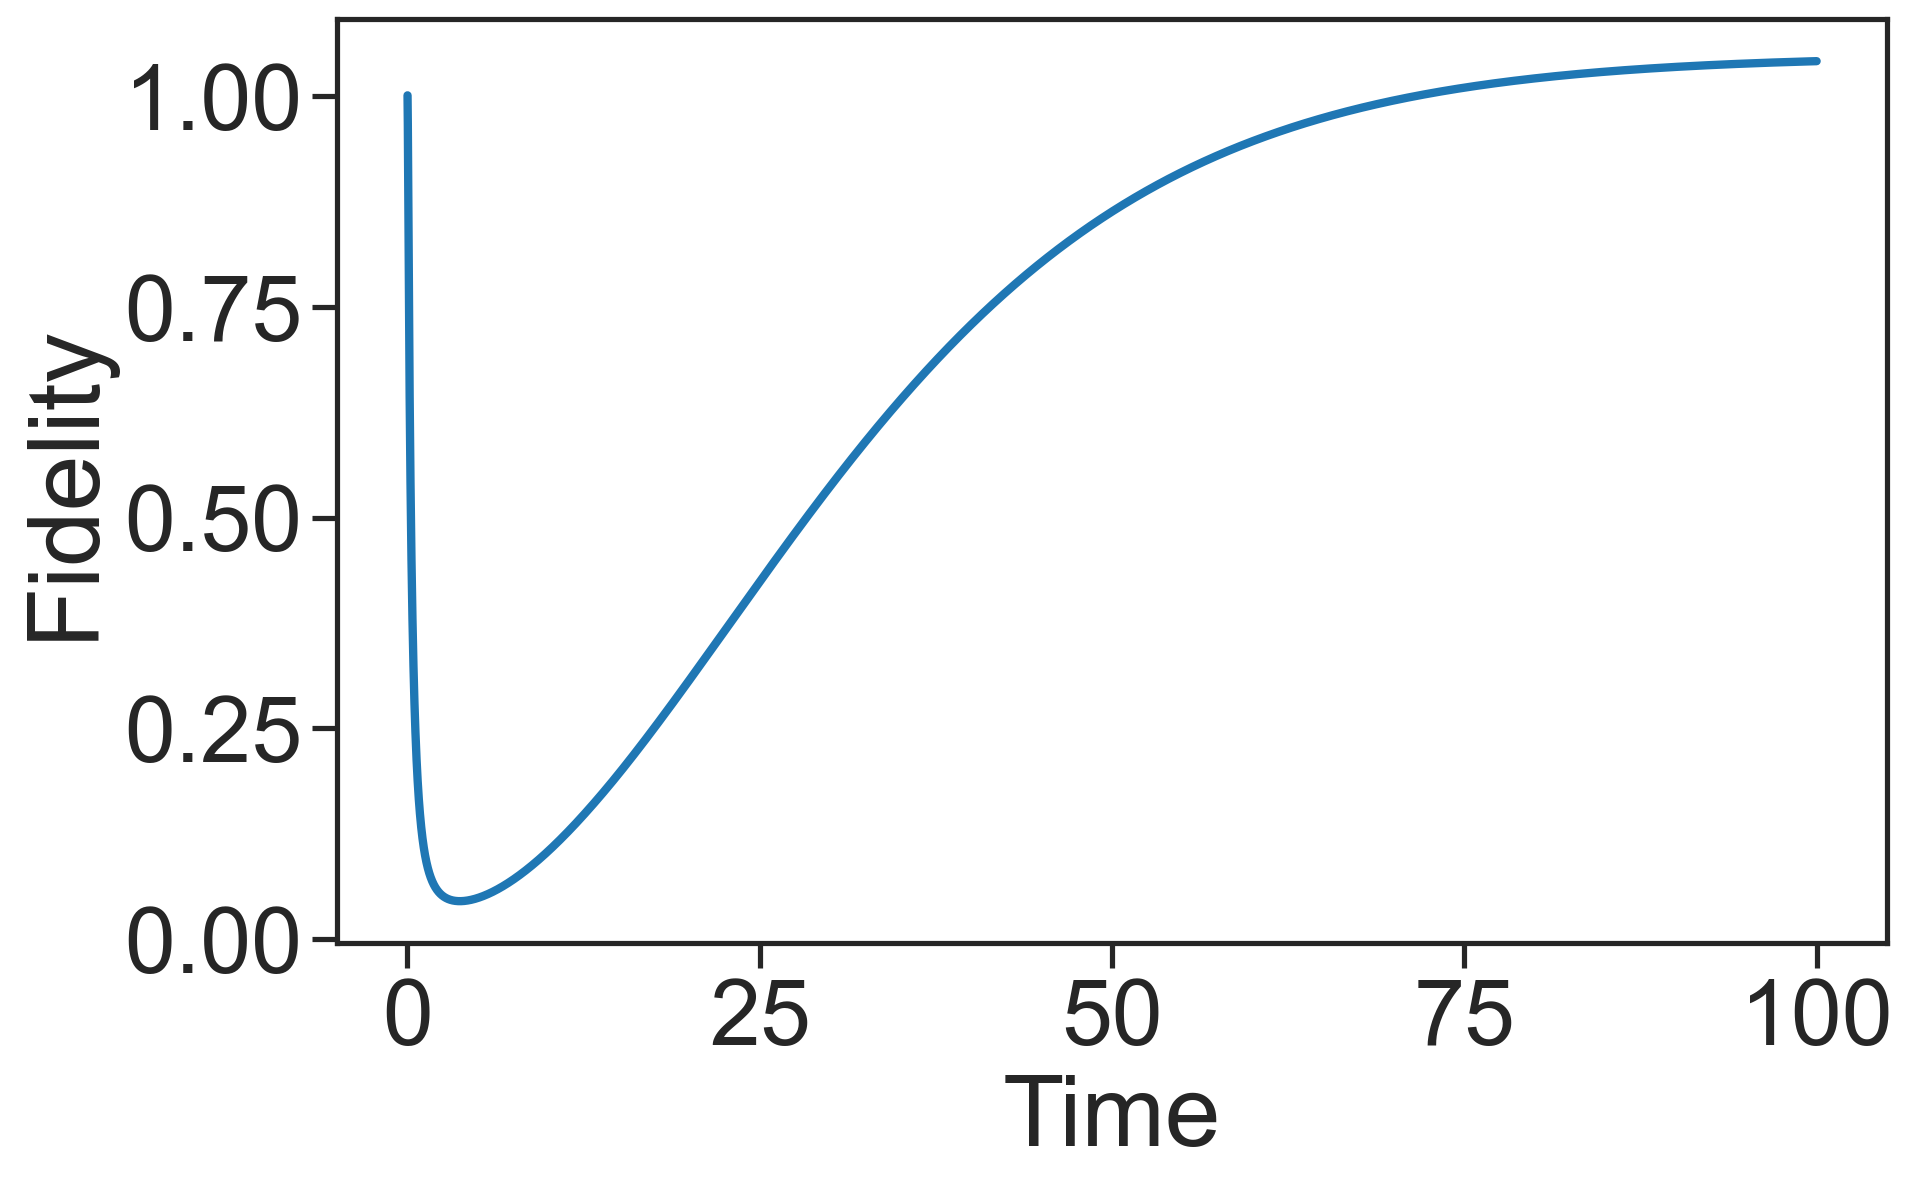

In [41]:

# Define the parameters
k_on = 1    # Example value for k_on
k_off_ER = 1e-1  # Example value for k_off_ER
k_off_EW = 1  # Example value for k_off_EW
k_p = 1      # Example value for k_p
k = 100      # Example value for k
k_cat = 0.00001     # Example value for k_cat

def model(y, t, k_on, k_off_ER, k_p, k, k_cat):
    E, R, ER, EpR, EppR, EpppR, EppppR, EpppppR = y
    
    dE_dt = -k_on * E * R  + k_off_ER * ER \
            + k_off_ER * EpR  \
            + k_off_ER * EppR  \
            + k_off_ER * EpppR \
            + k_off_ER * EppppR \
            + (k_off_ER + k_cat) * EpppppR
    
    dR_dt = -k_on * E * R + k_off_ER * ER + k_off_ER * EpR \
            + k_off_ER * EppR \
            + k_off_ER * EpppR \
            + k_off_ER * EppppR \
            + k_off_ER * EpppppR \
            
            
    dER_dt = k_on * E * R - k_off_ER * ER - (k_p - k * EpR) * ER 

    dEpR_dt = - (k_off_ER + k_p - k * EpR) * EpR + (k_p - k * EpR) * ER 


    dEppR_dt = - (k_off_ER + k_p - k * EpR) * EppR + (k_p - k * EpR) * EpR 

    dEpppR_dt =  - (k_off_ER + k_p - k * EpR) * EpppR + (k_p - k * EpR) * EppR 


    dEppppR_dt = - (k_off_ER + k_p - k * EpR) * EppppR + (k_p - k * EpR) * EpppR 


    dEpppppR_dt = - (k_off_ER + k_cat)  * EpppppR + (k_p - k * EpR) * EppppR 


    return [dE_dt, dR_dt, dER_dt, dEpR_dt, dEppR_dt, dEpppR_dt, dEppppR_dt, dEpppppR_dt]


# Initial concentrations
E0 = 1
R0 = 100000
#W0 = 100000
ER0 = 0.0
#EW0 = 0.0
EpR0 = 0.0
#EpW0 = 0.0
EppR0 = 0.0
#EppW0 = 0.0
EpppR0 = 0.0
#EpppW0 = 0.0
EppppR0 = 0.0
#EppppW0 = 0.0
EpppppR0 = 0.0
#EpppppW0 = 0.0


# Time points
t = np.linspace(0, 100, 10000)


# Solve the ODEs with the current parameter set
initial_conditions = [E0, R0, ER0, EpR0, EppR0, EpppR0, EppppR0, EpppppR0]
solution_ER = odeint(model, initial_conditions, t, args=(k_on, k_off_ER, k_p, k, k_cat))  # Ensure k_cat is passed in 'args'
solution_EW = odeint(model, initial_conditions, t, args=(k_on, k_off_EW, k_p, k, k_cat))  # Ensure k_cat is passed in 'args'


# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(t, solution[:, 0], label="E (Enzyme)")
#plt.plot(t, solution[:, 1], label="R (Substrate R)")
#plt.plot(t, solution[:, 2], label="W (Substrate W)")
plt.plot(t, solution_ER[:, 7], label="EpppppR (Enzyme-Substrate R)")
plt.plot(t, solution_EW[:, 7], label="EpppppW (Enzyme-Substrate W)")
#plt.plot(t, solution[:, 5], label="P (Product)")
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, solution_ER[:,7]/solution_EW[:,7])
plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.show()


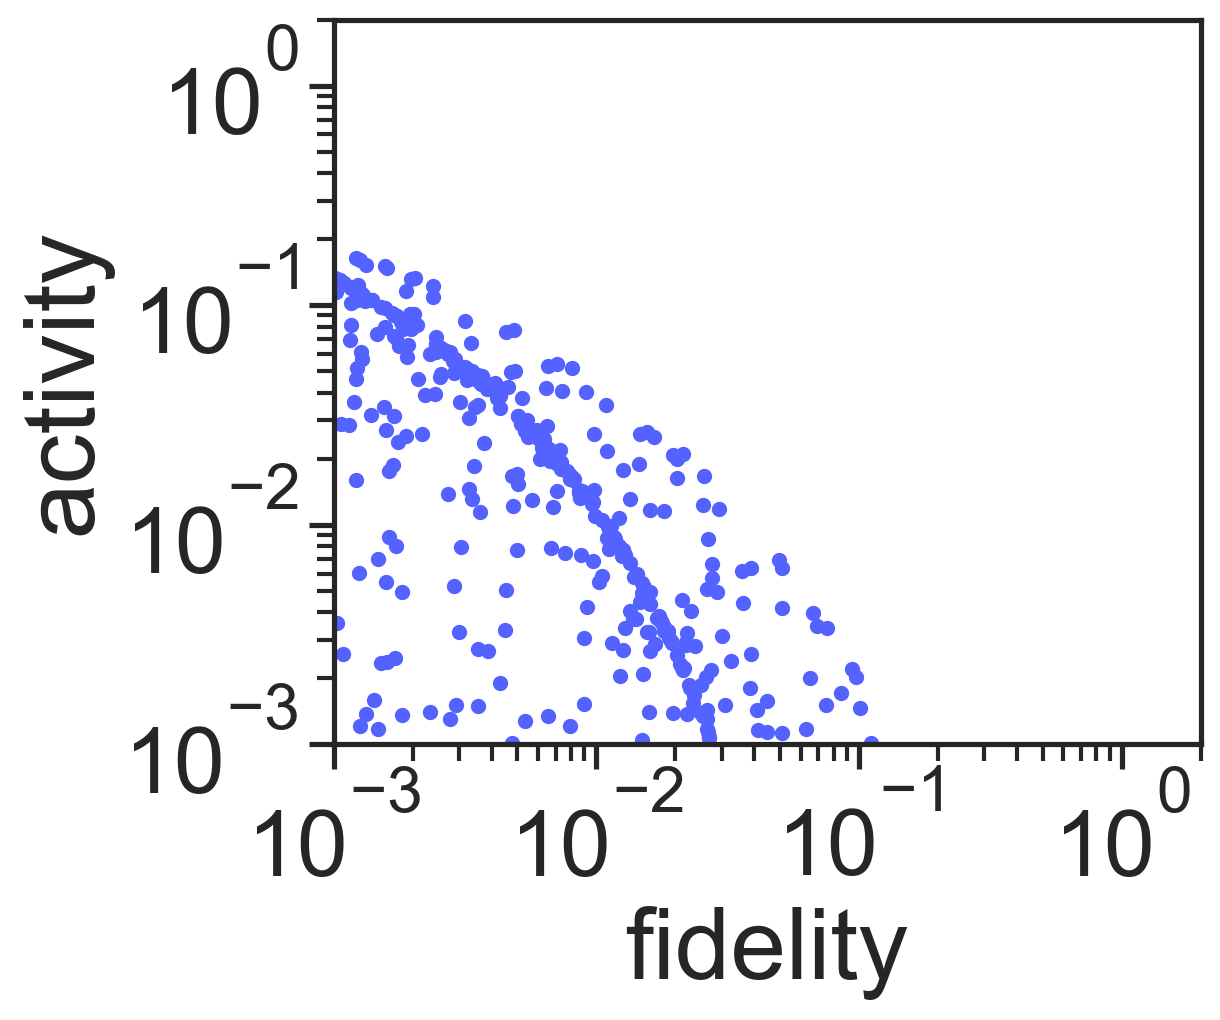

In [42]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

sns.set_context('talk',font_scale=2,rc={'lines.linewidth':3})

# Sampling parameters
n_pts =20000
000  # Number of parameter samples
min_log10 = -6  # Minimum log scale for sampling
max_log10 = 6   # Maximum log scale for sampling
n_dim = 5       # Number of parameters: k_on, k_off, k_p, k_cat
koff_r2w = 1e1  # koff_EW = koff * koff_r2w

# Generate log-uniform distributed parameters
kk = 10**(np.random.rand(n_pts, n_dim) * (max_log10 - min_log10) + min_log10)

# Optionally adjust some parameters, e.g., set k_on = k_p
# kk[:, 0] = kk[:, 2]  # Uncomment to make k_on = k_p

# Array to store results: each row will hold the results of one parameter set
result = np.zeros((n_pts, 3))  # Assuming 6 output variables (E*R, E*W, ratio, etc.)

# Define the function to calculate trade-off based on the parameters
def tradeoff_func(kvec, koff_r2w):
    k, k_on, k_off_ER, k_p, k_cat = kvec
    k_off_EW = k_off_ER * koff_r2w  # Set koff_EW = koff_ER * koff_r2w
    
    # Solve the ODE system with the current parameter set
    initial_conditions = [E0, R0, ER0, EpR0, EppR0, EpppR0, EppppR0, EpppppR0]

    solution_ER = odeint(model, initial_conditions, t, args=(k_on, k_off_ER, k_p, k, k_cat), rtol=1e-12
                         , atol=1e-8)
    solution_EW = odeint(model, initial_conditions, t, args=(k_on, k_off_EW, k_p, k, k_cat), rtol=1e-12
                         , atol=1e-8)

    # Extract steady-state concentrations (assumed to be at the last time point)
    E_star_R_steady = solution_ER[-1, 7]  # E*R concentration
    E_star_W_steady = solution_EW[-1, 7]  # E*W concentration
    
    # Calculate the ratio E*R / E*W
    if E_star_W_steady != 0:
        ratio = E_star_R_steady / E_star_W_steady
    else:
        ratio = np.nan  # If E*W is zero, the ratio is undefined
    
    # Return multiple results: E*R, E*W, ratio, and other relevant results
    return [E_star_R_steady, E_star_W_steady, ratio]

# Loop through all the parameter sets and compute results
for i in range(n_pts):
    kvec = kk[i, :]  # Get the current set of parameters
    result[i] = tradeoff_func(kvec, koff_r2w)  # Calculate and store results for this parameter set    
    # Print out the parameter set for every iteration
    #print(f"Parameter set {i+1}: k={kvec[0]}, k_on={kvec[1]}, k_off_ER={kvec[2]}, k_p={kvec[3]}, k_cat={kvec[4]}")
# Filter results based on the x and y limits (log scale)
x_limit_min = 1e-3
x_limit_max = 2
y_limit_min = 1e-3
y_limit_max = 2

# Apply the limits to only show the points in the desired range
filtered_result = result[(result[:, 2] / 1e6 >= x_limit_min) & (result[:, 2] / 1e6 <= x_limit_max) &
                         (result[:, 0] >= y_limit_min) & (result[:, 0] <= y_limit_max)]

# Plot the results: E*R vs E*R/E*W
plt.subplots(1, 1,figsize=(7,6))
# Plot the filtered results
plt.scatter(filtered_result[:, 2] / 1e6, filtered_result[:, 0], color='#5463FF', s=16, alpha=1)  # Plot ratio vs E*R

#plt.scatter(result[:, 2]/1e6, result[:, 0], color='#8CA9FF', s=10, alpha=0.7)  # Plot ratio vs E*R

xx=np.logspace(-3,0,1000)
#plt.plot(xx,1-xx,lw=3,color='r',label='$\eta+c=1$')
#plt.plot(xx,(1-xx**(1/6))**6,lw=3,color='b',label=r'$\eta=c(\frac{1}{\sqrt{c}}-1)^2$')

plt.ylabel(r'activity')  # Label for x-axis (ratio E*R / E*W)/6++++++++++++++++++++++++++++++
plt.xlabel(r'fidelity')  # Label for y-axis (E*R concentration)
#plt.title('Parameter Sweep: $[E^*R]$ vs $[E^*R]/[E^*W]$')  # Plot title
plt.ylim([1e-3, 2])  # Set y-axis limits
plt.xlim([1e-3, 2])  # Set x-axis limits
plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale
#plt.legend()
#plt.grid(True, which="both", ls="--")  # Enable grid lines
plt.savefig(f'N=5_negative feedback_varying k.svg', bbox_inches='tight', transparent=True)
plt.tight_layout()  # Adjust plot layout
plt.show()  # Display the plot



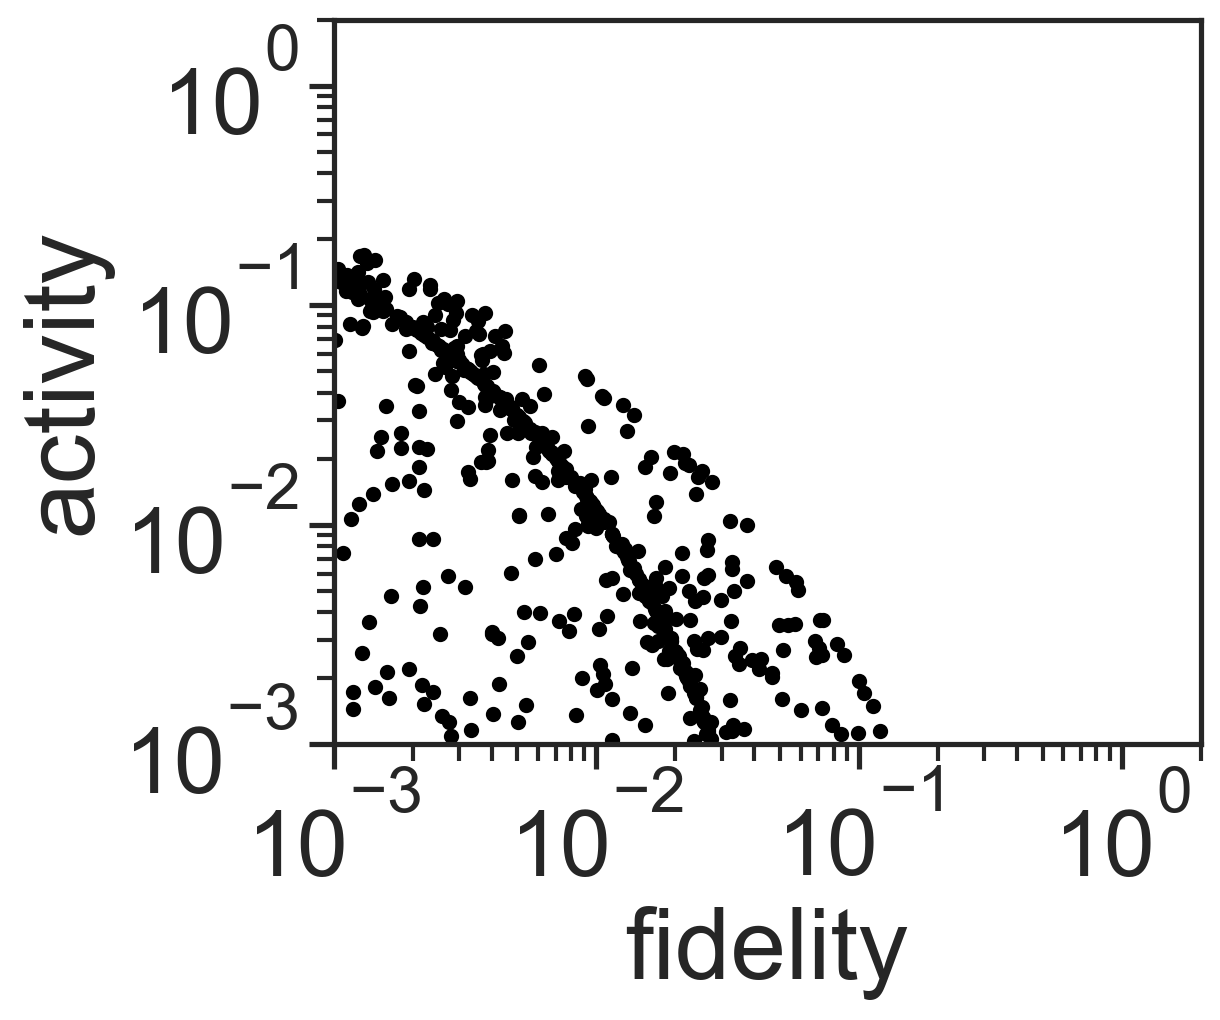

In [43]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Sampling parameters
n_pts = 20000 # Number of parameter samples
min_log10 = -6  # Minimum log scale for sampling
max_log10 = 6   # Maximum log scale for sampling
n_dim = 4       # Number of parameters: k_on, k_off, k_p, k_cat
koff_r2w = 1e1  # koff_EW = koff * koff_r2w

# Generate log-uniform distributed parameters
kk = 10**(np.random.rand(n_pts, n_dim) * (max_log10 - min_log10) + min_log10)

# Optionally adjust some parameters, e.g., set k_on = k_p
# kk[:, 0] = kk[:, 2]  # Uncomment to make k_on = k_p

# Array to store results: each row will hold the results of one parameter set
result = np.zeros((n_pts, 3))  # Assuming 6 output variables (E*R, E*W, ratio, etc.)

# Define the function to calculate trade-off based on the parameters
def tradeoff_func(kvec, koff_r2w):
    k_on, k_off_ER, k_p, k_cat = kvec
    k_off_EW = k_off_ER * koff_r2w  # Set koff_EW = koff_ER * koff_r2w
    k = 0
    # Solve the ODE system with the current parameter set
    initial_conditions = [E0, R0, ER0, EpR0, EppR0, EpppR0, EppppR0, EpppppR0]

    solution_ER = odeint(model, initial_conditions, t, args=(k_on, k_off_ER, k_p, k, k_cat), rtol=1e-12
                         , atol=1e-8)
    solution_EW = odeint(model, initial_conditions, t, args=(k_on, k_off_EW, k_p, k, k_cat), rtol=1e-12
                         , atol=1e-8)

    # Extract steady-state concentrations (assumed to be at the last time point)
    E_star_R_steady = solution_ER[-1, 7]  # E*R concentration
    E_star_W_steady = solution_EW[-1, 7]  # E*W concentration
    
    # Calculate the ratio E*R / E*W
    if E_star_W_steady != 0:
        ratio = E_star_R_steady / E_star_W_steady
    else:
        ratio = np.nan  # If E*W is zero, the ratio is undefined
    
    # Return multiple results: E*R, E*W, ratio, and other relevant results
    return [E_star_R_steady, E_star_W_steady, ratio]

# Loop through all the parameter sets and compute results
for i in range(n_pts):
    kvec = kk[i, :]  # Get the current set of parameters
    result[i] = tradeoff_func(kvec, koff_r2w)  # Calculate and store results for this parameter set


# Filter results based on the x and y limits (log scale)
x_limit_min = 1e-3
x_limit_max = 2
y_limit_min = 1e-3
y_limit_max = 2

# Apply the limits to only show the points in the desired range
filtered_result = result[(result[:, 2] / 1e6 >= x_limit_min) & (result[:, 2] / 1e6 <= x_limit_max) &
                         (result[:, 0] >= y_limit_min) & (result[:, 0] <= y_limit_max)]


# Plot the results: E*R vs E*R/E*W
plt.subplots(1, 1,figsize=(7,6))
# Plot the filtered results
plt.scatter(filtered_result[:, 2] / 1e6, filtered_result[:, 0], color='black', s=16, alpha=1)  # Plot ratio vs E*R
#plt.scatter(result[:, 2]/1e6, result[:, 0], color='#ff7f0e', s=10, alpha=0.7)  # Plot ratio vs E*R

xx=np.logspace(-3,0,1000)
#plt.plot(xx,1-xx,lw=3,color='r',label='$\eta+c=1$')
#plt.plot(xx,(1/xx**(1/6)-1)**6*xx,lw=3,color='b',label=r'$\eta=c(\frac{1}{\sqrt{c}}-1)^2$')

plt.ylabel(r'activity')  # Label for x-axis (ratio E*R / E*W)
plt.xlabel(r'fidelity')  # Label for y-axis (E*R concentration)
#plt.title('Parameter Sweep: $[E^*R]$ vs $[E^*R]/[E^*W]$')  # Plot title
plt.ylim([1e-3, 2])  # Set y-axis limits
plt.xlim([1e-3, 2])  # Set x-axis limits
plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale
#plt.legend()
#plt.grid(True, which="both", ls="--")  # Enable grid lines
plt.savefig(f'N=5_negative feedback_k=0.svg', bbox_inches='tight', transparent=True)
plt.tight_layout()  # Adjust plot layout
plt.show()  # Display the plot

